In [1]:
import pickle

import numpy as np
from numpy import random as rnd
from matplotlib import pyplot as plt
from tqdm import autonotebook as tqdm

from sklearn.model_selection import train_test_split
from utils import find_energies

/var/folders/xb/gm1t4x5j3sbby4s80ty5k3z40000gn/T/ipykernel_5959/1674584858.py:6: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm import autonotebook as tqdm


In [2]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import losses

In [3]:
with open("data/dataset.bin", mode="rb") as fh:
    data = pickle.load(fh)

In [4]:
x = np.array(data[0]["space"])

In [5]:
num_examples = len(data)
num_points = len(data[0]["space"])

potentials = np.zeros((num_examples, num_points))
wave_functions = np.zeros((num_examples, num_points))
energies = np.zeros((num_examples, 4))
num_levels = np.zeros(num_examples)

for k, item in enumerate(data):
    potentials[k] = item["potential"]
    wave_functions[k] = item["states"][0]["wave_function"]
    energies[k, 0:len(item["states"])] = [state["energy"] for state in item["states"]]
    num_levels[k] = len(item["states"])
    
    

In [6]:
train_pot, test_pot, train_wf, test_wf, train_en, test_en = train_test_split(potentials, wave_functions, energies)

In [7]:
v_input = keras.Input(shape=(300,1))

internal_embedding = v_input
for k in range(5):
    internal_embedding = layers.Conv1D(16, 5, activation="relu")(internal_embedding)
    internal_embedding = layers.Dropout(0.1)(internal_embedding)

internal_embedding = layers.Flatten(name="embedding")(internal_embedding)
    
energy = layers.Dense(4, name="energy", activation="linear")(internal_embedding)

# psi_embedding = internal_embedding
# for k in range(4):
#     psi_embedding = layers.Conv1DTranspose(1, 30, activation="relu")(psi_embedding)
    
# psi = layers.Conv1DTranspose(1, 30, activation="linear", name="psi")(psi_embedding)


model = keras.Model(inputs=v_input, outputs=energy)

In [8]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 300, 1)]          0         
                                                                 
 conv1d (Conv1D)             (None, 296, 16)           96        
                                                                 
 dropout (Dropout)           (None, 296, 16)           0         
                                                                 
 conv1d_1 (Conv1D)           (None, 292, 16)           1296      
                                                                 
 dropout_1 (Dropout)         (None, 292, 16)           0         
                                                                 
 conv1d_2 (Conv1D)           (None, 288, 16)           1296      
                                                                 
 dropout_2 (Dropout)         (None, 288, 16)           0     

In [9]:
model.compile(optimizer="adam", loss="mean_absolute_error") #loss={"energy": "mean_squared_error", "psi": "mean_absolute_error"})

In [10]:
history = model.fit(train_pot, train_en, validation_data=(test_pot, test_en), epochs=40)
          
#[train_en, train_wf], validation_split=0.1, epochs=10)

Epoch 1/40
234/234 [==============================] - 5s 17ms/step - loss: 6.1068 - val_loss: 12.3919
Epoch 2/40
234/234 [==============================] - 4s 16ms/step - loss: 4.2958 - val_loss: 12.5748
Epoch 3/40
234/234 [==============================] - 4s 16ms/step - loss: 3.8446 - val_loss: 11.0936
Epoch 4/40
234/234 [==============================] - 4s 16ms/step - loss: 3.4363 - val_loss: 12.4900
Epoch 5/40
234/234 [==============================] - 4s 16ms/step - loss: 3.1334 - val_loss: 10.5469
Epoch 6/40
234/234 [==============================] - 4s 16ms/step - loss: 2.8604 - val_loss: 11.9801
Epoch 7/40
234/234 [==============================] - 4s 16ms/step - loss: 2.7947 - val_loss: 12.0811
Epoch 8/40
234/234 [==============================] - 4s 16ms/step - loss: 2.4868 - val_loss: 10.5636
Epoch 9/40
234/234 [==============================] - 4s 16ms/step - loss: 2.3121 - val_loss: 11.8231
Epoch 10/40
234/234 [==============================] - 4s 16ms/step - loss: 2.2068

78/78 [==============================] - 0s 2ms/step


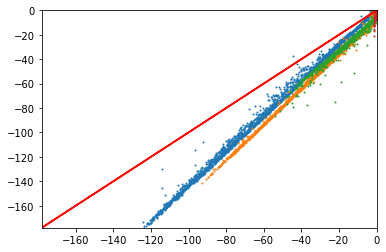

In [11]:
pred_en = model.predict(test_pot)

for k in range(4):
    plt.scatter(pred_en[:, k], test_en[:, k], s=1)
    plt.plot([test_en.min(), 0], [test_en.min(), 0], color="red")
    plt.xlim(test_en.min(), 0)
    plt.ylim(test_en.min(), 0)

In [12]:
# plt.plot(history.history['val_loss'])

In [13]:
pot_a = np.where( (x > 0) & (x < 1), -200, 0)
pot_b = pot_a + np.where( np.abs(x-0.5) < 0.1, 1200, 0)

potentials = np.zeros((100, pot_a.shape[0]))
scales = np.linspace(0, 1, 100)
actual_energies = np.zeros((100, 4))

for k, scale in enumerate(tqdm.tqdm(scales)):
    potentials[k] = pot_a * scale + pot_b * (1 - scale)
    results = [e for (e, _) in find_energies(x, potentials[k])]
    if len(results) > 0:
        actual_energies[k, 0:len(actual_energies)] = min(results)

  0%|          | 0/100 [00:00<?, ?it/s]

4/4 [==============================] - 0s 2ms/step


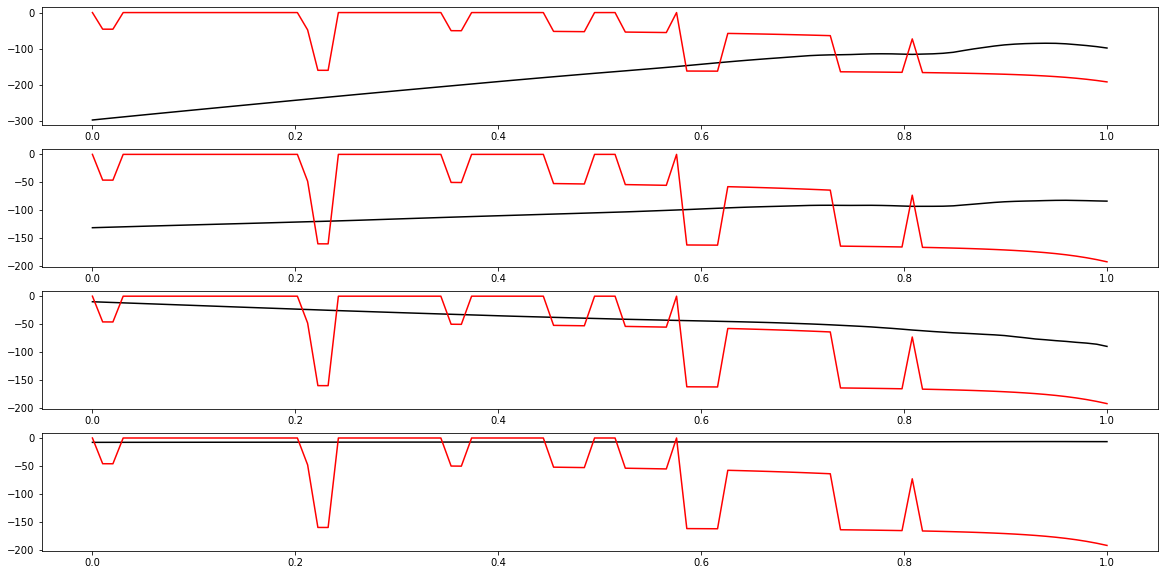

In [14]:
fig, ax = plt.subplots(nrows=4, figsize=(20, 10))
pred_energies = model.predict(potentials)

for k in range(4):
    ax[k].plot(scales, pred_energies[:, k], color="black")
    ax[k].plot(scales, actual_energies[:, k], color="red")

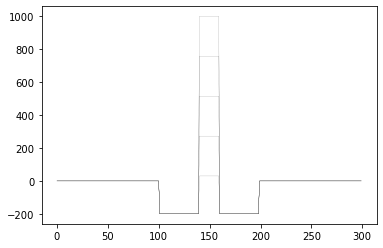

In [15]:
_ = plt.plot(potentials[::20].T, color="black", lw=0.1)
# _ = plt.plot(pot_a, color="red", lw=1)
# _ = plt.plot(pot_b, color="red", lw=1)